In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install matplotlib-venn
from matplotlib_venn import venn2
!pip install Jinja2
!pip install nbconvert


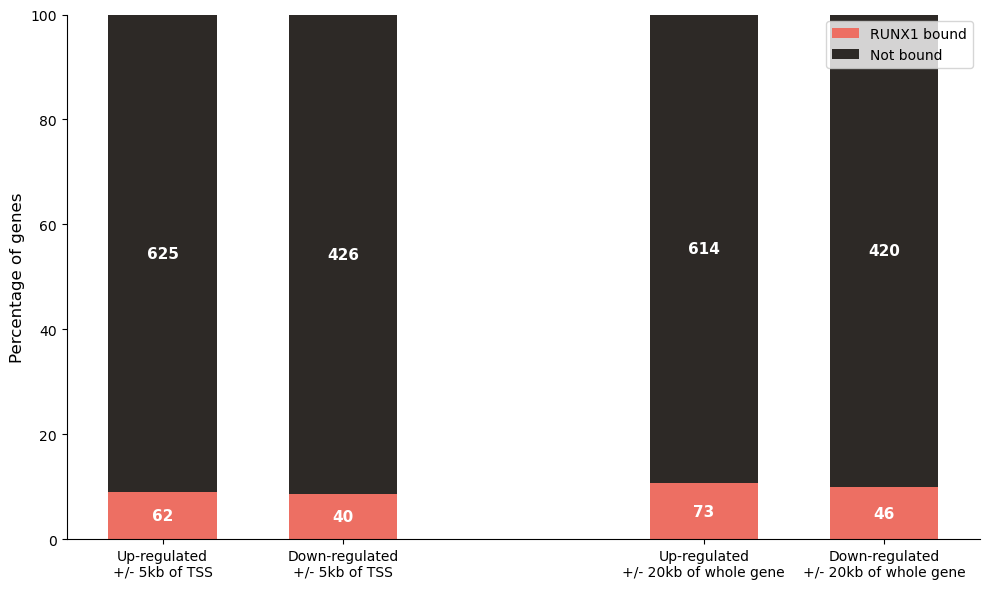

In [9]:
# Figure 2F -

rnaseq = pd.read_csv('GSE75070_MCF7_shRUNX1_shNS_RNAseq_log2_foldchange.txt', sep='\t')
peaks = pd.read_csv('results/annotated_peaks.txt', sep='\t')

significant = rnaseq[(rnaseq['padj'] < 0.01) & (abs(rnaseq['log2FoldChange']) > 1)].copy()

significant['regulation'] = significant['log2FoldChange'].apply(
    lambda x: 'Up-regulated' if x > 1 else 'Down-regulated'
)

peaks['Gene Name'] = peaks['Gene Name'].str.strip()

genes_with_peaks_5kb = set()
genes_with_peaks_20kb = set()

for _, peak in peaks.iterrows():
    gene = peak['Gene Name']
    dist_to_tss = peak['Distance to TSS']
    
    if pd.isna(gene) or gene == '':
        continue

    if abs(dist_to_tss) <= 5000:
        genes_with_peaks_5kb.add(gene)
    
    if abs(dist_to_tss) <= 20000:
        genes_with_peaks_20kb.add(gene)

significant['has_peak_5kb'] = significant['genename'].isin(genes_with_peaks_5kb)
significant['has_peak_20kb'] = significant['genename'].isin(genes_with_peaks_20kb)

def count_categories(df, peak_column):
    """Count genes with and without RUNX1 binding for up/down regulated genes"""
    results = {}
    
    for reg_type in ['Up-regulated', 'Down-regulated']:
        subset = df[df['regulation'] == reg_type]
        
        runx1_bound = subset[peak_column].sum()
        not_bound = len(subset) - runx1_bound
        total = len(subset)
        
        results[reg_type] = {
            'RUNX1_bound': int(runx1_bound),
            'Not_bound': int(not_bound),
            'total': total
        }
    
    return results

counts_5kb = count_categories(significant, 'has_peak_5kb')
counts_20kb = count_categories(significant, 'has_peak_20kb')

fig, ax = plt.subplots(figsize=(10, 6))

categories = ['Up-regulated', 'Down-regulated', 'Up-regulated', 'Down-regulated']
x_positions = [0, 1, 3, 4]
x_labels = ['Up-regulated\n+/- 5kb of TSS', 'Down-regulated\n+/- 5kb of TSS',
            'Up-regulated\n+/- 20kb of whole gene', 'Down-regulated\n+/- 20kb of whole gene']

bound_counts = [
    counts_5kb['Up-regulated']['RUNX1_bound'],
    counts_5kb['Down-regulated']['RUNX1_bound'],
    counts_20kb['Up-regulated']['RUNX1_bound'],
    counts_20kb['Down-regulated']['RUNX1_bound']
]

not_bound_counts = [
    counts_5kb['Up-regulated']['Not_bound'],
    counts_5kb['Down-regulated']['Not_bound'],
    counts_20kb['Up-regulated']['Not_bound'],
    counts_20kb['Down-regulated']['Not_bound']
]

totals = [
    counts_5kb['Up-regulated']['total'],
    counts_5kb['Down-regulated']['total'],
    counts_20kb['Up-regulated']['total'],
    counts_20kb['Down-regulated']['total']
]

bound_pct = [b/t*100 if t > 0 else 0 for b, t in zip(bound_counts, totals)]
not_bound_pct = [n/t*100 if t > 0 else 0 for n, t in zip(not_bound_counts, totals)]

width = 0.6
p1 = ax.bar(x_positions, bound_pct, width, label='RUNX1 bound', color='#ed6f63')
p2 = ax.bar(x_positions, not_bound_pct, width, bottom=bound_pct, label='Not bound', color='#2D2926')

for i, (x, b, n, b_pct, n_pct) in enumerate(zip(x_positions, bound_counts, not_bound_counts, bound_pct, not_bound_pct)):
    if b > 0:
        ax.text(x, b_pct/2, str(b), ha='center', va='center', 
                fontsize=11, fontweight='bold', color='white')
    
    if n > 0:
        ax.text(x, b_pct + n_pct/2, str(n), ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')

ax.set_ylabel('Percentage of genes', fontsize=12)
ax.set_ylim(0, 100)
ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontsize=10)
ax.legend(loc='upper right', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figure_2f_recreation.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Figure S2A - Table

df=pd.read_csv('samtools-flagstat-dp.tsv', sep='\t')
df2=df.drop(columns=["Duplicates", "Paired in Sequencing", "Properly Paired", "Self and mate mapped", "Singletons", "Diff chr (mapQ >= 5)", "Mate mapped to diff chr", "Mapped", "Sample"])
df2["Biological Replicate"] = [1,2,1,2]

df3 = df2.rename(columns={
    "Total Reads": "Raw Reads",
    "Total Passed QC": "Mapped Reads"
})

df4 = df3.rename(index={
    "INPUT_rep1_flagstat": "INPUT Rep1",
    "INPUT_rep2_flagstat": "INPUT Rep2",
    "IP_rep1_flagstat": "IP Rep1",
    "IP_rep2_flagstat": "IP Rep2"
})

df4[["Raw Reads", "Mapped Reads"]] = df4[["Raw Reads", "Mapped Reads"]] * 1000000

styled = df4.style.set_properties(**{'text-align': 'center'}).format("{:,}")
styled  # do NOT print(), just leave it as the last line




,Raw Reads,Mapped Reads,Biological Replicate
INPUT Rep1,"30,075,142.0","28,253,593.0",1
INPUT Rep2,"10,900,442.0","10,069,440.0",2
IP Rep1,"29,734,121.0","27,969,494.0",1
IP Rep2,"29,988,988.0","28,351,783.0",2


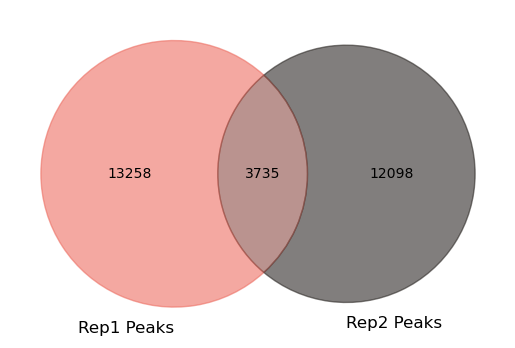

In [26]:
#Figure S2C


df1=pd.read_csv('results/rep1_peaks.txt', header=None, dtype=str)
total_peaks1_line = df1[df1[0].str.contains("total peaks", na=False)]
rep1_peaks = int(total_peaks1_line.iloc[0, 0].split("=")[1].strip())

df2=pd.read_csv('results/rep2_peaks.txt', header=None, dtype=str)
total_peaks2_line = df2[df2[0].str.contains("total peaks", na=False)]
rep2_peaks = int(total_peaks2_line.iloc[0, 0].split("=")[1].strip())

df3=pd.read_csv('results/repr_peaks_filtered.bed', sep="\t", header=None)
downstream_peaks=len(df3)

v=venn2(subsets = (rep1_peaks, rep2_peaks, downstream_peaks), set_labels = ('Rep1 Peaks', 'Rep2 Peaks'))

v.get_patch_by_id('10').set_color('#ed6f63')   # Left set
v.get_patch_by_id('01').set_color('#2D2926')   # Right set
v.get_patch_by_id('11').set_color('#8D4C44')   # Overlap
for patch in ['10', '01', '11']:
    v.get_patch_by_id(patch).set_alpha(0.6)

plt.show()

In [44]:
import pandas as pd

# Read the HOMER annotated peaks file
annotated_peaks = pd.read_csv('results/annotated_peaks.txt', sep='\t')

# Extract the 'Gene Name' column
gene_list = annotated_peaks['Gene Name'].dropna().unique().tolist()

# Clean up the list - remove empty strings and generic placeholders
gene_list = [g.strip() for g in gene_list if g and str(g).strip() not in ['', '.', 'NA', 'na', '-', 'nan']]

print(f"Total unique genes: {len(gene_list)}")
print(f"\nFirst 20 genes:")
print(gene_list[:20])

# Save to a text file (Enrichr-friendly format - one gene per line)
with open('gene_list_for_enrichr.txt', 'w') as f:
    f.write('\n'.join(gene_list))

print(f"\nGene list saved to 'gene_list_for_enrichr.txt'")
print("You can upload this file directly to Enrichr at: https://maayanlab.cloud/Enrichr/")

# Also save as a single-column dataframe
gene_df = pd.DataFrame(gene_list, columns=['Gene_Name'])
gene_df.to_csv('gene_list.csv', index=False, header=False)

print("\nAlternatively, here's the list formatted for copy-paste:")
print('\n'.join(gene_list))

Total unique genes: 3361

First 20 genes:
['GPBP1L1', 'ZNF786', 'MIR3928', 'PADI4', 'Y_RNA', 'CPQ', 'GPR160', 'MTMR1', 'TSPYL5', 'STAG3L4', 'ENSG00000248954', 'UVSSA', 'MAZ', 'ARMC8', 'GSE1', 'CAND1', 'TMEM267', 'PRR5', 'RPL3P6', 'RSBN1']

Gene list saved to 'gene_list_for_enrichr.txt'
You can upload this file directly to Enrichr at: https://maayanlab.cloud/Enrichr/

Alternatively, here's the list formatted for copy-paste:
GPBP1L1
ZNF786
MIR3928
PADI4
Y_RNA
CPQ
GPR160
MTMR1
TSPYL5
STAG3L4
ENSG00000248954
UVSSA
MAZ
ARMC8
GSE1
CAND1
TMEM267
PRR5
RPL3P6
RSBN1
ZFAT
ENSG00000223774
HJV
TAMM41
PLEC
SMAD9
BTD
EIF2B5
TTC5
ZNF48
MYRF-AS1
TLE3
MACF1
PSMA1
EIF1B-AS1
ENSG00000226999
PXYLP1
RBBP8NL
PLEKHA8
KRT18
LINC00205
GRB2
TPM1
PLA2G6
HSP90AB1
PHF6
ATXN7
RAB15
MIR3194
NDUFB4
EPS15L1
EMILIN1
DHX33-DT
ENSG00000260111
LINGO1
NPL
GRPEL2
STARD13
ENSG00000245869
GPR137
CYP24A1
CDC42SE1
ENSG00000278922
NPEPPS
DOK5
SPINK4
RPL21P93
MINDY1
AP5Z1
ZNF821
RN7SL236P
AADAT
MIR4686
PCYT1A
ADCY5
ENSG00000279262